<center>
<h1> TP-Projet d'optimisation numérique </h1>
<h1> Algorithme du lagrangien augmenté </h1>
</center>

## Implémentation

1. Implémenter l'algorithme du lagrangien augmenté, en utilisant les différentes méthodes
qui ont été vues en première partie pour la résolution de la suite de problèmes sans
contraintes (fichier `src/lagrangien_augmente.jl`). La spécification est donnée dans le fichier.
2. Vérifier que les tests ci-dessous passent.

In [1]:
include("../src/lagrangien_augmente.jl")
include("../test/tester_lagrangien_augmente.jl")

#
afficher = true # si true, alors affiche les résultats des algorithmes

#
tester_lagrangien_augmente(lagrangien_augmente, afficher);

Affichage des résultats des algorithmes : true

-------------------------------------------------------------------------
Résultats de : LA et newton appliqué à f1:
  * x0       = [0, 1, 1]
  * x_sol    = [0.5000042424566808, 1.2499978787716595, 0.5000042424566811]
  * f(x_sol) = 2.249961818051857
  * nb_iters = 7
  * flag     = 0
  * solution = [0.5, 1.25, 0.5]
-------------------------------------------------------------------------
Résultats de : LA et newton appliqué à f1:
  * x0       = [0.5, 1.25, 1.0]
  * x_sol    = [0.5000042424566808, 1.2499978787716595, 0.5000042424566811]
  * f(x_sol) = 2.249961818051857
  * nb_iters = 7
  * flag     = 0
  * solution = [0.5, 1.25, 0.5]
-------------------------------------------------------------------------
Résultats de : LA et newton appliqué à f2:
  * x0       = [1, 0]
  * x_sol    = [0.9072336571162266, 0.8227549044924193]
  * f(x_sol) = 0.008615707033558758
  * nb_iters = 5
  * flag     = 0
  * solution = [0.9072339605110892, 0.82275545

## Interprétation

 1. Commenter les résultats obtenus, en étudiant notamment les valeurs de $\lambda_k$ et $\mu_k$ au fil des itérations.
 2. Dans la méthode du lagrangien augmenté, la convergence est généralement suivie à l’aide de deux conditions: le résidu de faisabilité, qui mesure la violation de la contrainte $c(x) = 0$, et le gradient du lagrangien augmenté. Observez l’évolution de ces deux grandeurs au cours de vos expérimentations numériques. Laquelle des deux a tendance à converger plus rapidement, et pourquoi ce comportement se manifeste-t-il compte tenu de l’augmentation progressive du paramètre de pénalité $\mu_k$?
 3. Expliquez pourquoi le paramètre de pénalité $\mu_k$ augmente généralement à chaque itération externe. Que peut-il se passer s’il est augmenté trop rapidement ou, au contraire, pas suffisamment?
 4. À l’aide d’un exemple numérique de votre choix, démontrez l’impact de $\mu_k$ sur le mauvais conditionnement de la hessienne du lagrangien augmenté. Comment ce phénomène influence-t-il le coût de calcul des solveurs sans contraintes utilisés?
 5. À l’aide d’un exemple de votre choix, testez l’algorithme pour différentes valeurs initiales du paramètre de pénalité $\mu_0$. Tracez la violation de contrainte $\|c(x_k)\|$ ainsi que la norme du gradient du lagrangien augmenté au fil des itérations. Discutez comment le choix de $\mu_0$ influence la vitesse de convergence et la stabilité de l’algorithme.
 6. Tracez l’évolution de $\lambda_k$ au cours des itérations externes. Converge-t-il vers une valeur significative? Que se passe-t-il si la contrainte n’est pas exactement satisfaite?
 7. Étudier l'influence du paramètre $\tau$ dans la performance de l'algorithme. Pour cela Vous réaliserez des tests numériques.
 8. Expliquez comment le choix de différents solveurs de sous-problèmes influence la convergence de la méthode du lagrangien augmenté. Une solution de haute précision du problème interne est-elle toujours nécessaire ? Pourquoi ou pourquoi pas ?


Test avec Newton :

Test avec RC-GCT :

Test avec RC-Cauchy :

COMPARAISON DES MÉTHODES
Méthode      | Itérations | f_final      | ‖c(x)‖_final | λ_final
---------------------------------------------------------------------------
Newton       |          7 | 8.6157e-03 | 3.7850e-11     | 0.0387
RC-GCT       |          7 | 8.6157e-03 | 2.9818e-11     | 0.0387
RC-Cauchy    |         13 | 8.6157e-03 | 2.7791e-09     | 0.0387


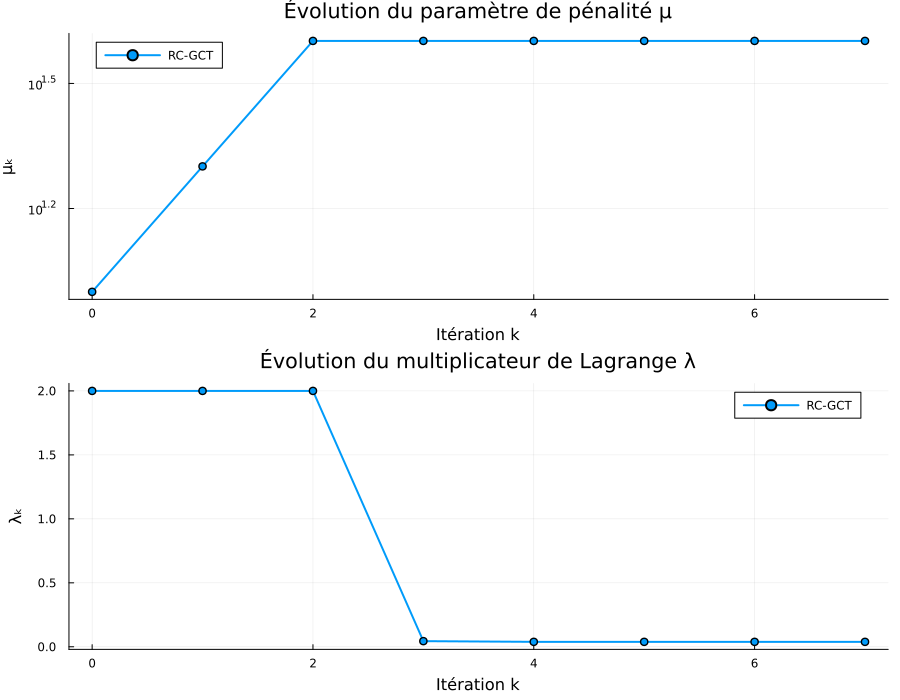

In [9]:
# Expérimentations numériques à faire ici.
# Vous pouvez utiliser le package Plots pour les affichages de courbes: using Plots
#Graph pour question 1
using Plots, LinearAlgebra, Printf

# Charger les fonctions
include("../test/fonctions_de_tests.jl")
include("../src/lagrangien_augmente.jl")


# Test sur f2 avec contrainte circulaire
f = fct2
∇f = grad_fct2
∇²f = hess_fct2
c = contrainte2  # (x₁)² + (x₂)² - 1.5
∇c = grad_contrainte2
∇²c = hess_contrainte2

x0 = pts2.x03  # [1, 0]

# Ou créer une version avec historique

println("\nTest avec Newton :")
x_sol_n, f_sol_n, flag_n, nb_n, μs_n, λs_n = 
    lagrangien_augmente(f, ∇f, ∇²f, c, ∇c, ∇²c, x0, algo_noc="newton")

println("\nTest avec RC-GCT :")
x_sol_g, f_sol_g, flag_g, nb_g, μs_g, λs_g = 
    lagrangien_augmente(f, ∇f, ∇²f, c, ∇c, ∇²c, x0, algo_noc="rc-gct")

println("\nTest avec RC-Cauchy :")
x_sol_c, f_sol_c, flag_c, nb_c, μs_c, λs_c = 
    lagrangien_augmente(f, ∇f, ∇²f, c, ∇c, ∇²c, x0, algo_noc="rc-cauchy")

# Afficher les résultats
println("\n" * "="^75)
println("COMPARAISON DES MÉTHODES")
println("="^75)
println("Méthode      | Itérations | f_final      | ‖c(x)‖_final | λ_final")
println("-"^75)
@printf("Newton       | %10d | %.4e | %.4e     | %.4f\n", 
        nb_n, f_sol_n, abs(c(x_sol_n)), λs_n[end])
@printf("RC-GCT       | %10d | %.4e | %.4e     | %.4f\n", 
        nb_g, f_sol_g, abs(c(x_sol_g)), λs_g[end])
@printf("RC-Cauchy    | %10d | %.4e | %.4e     | %.4f\n", 
        nb_c, f_sol_c, abs(c(x_sol_c)), λs_c[end])

# Graphiques d'évolution
p1 = plot(0:nb_g, μs_g, 
         xlabel="Itération k", ylabel="μₖ", 
         title="Évolution du paramètre de pénalité μ",
         yscale=:log10, lw=2, marker=:circle, label="RC-GCT")
         
p2 = plot(0:nb_g, λs_g,
         xlabel="Itération k", ylabel="λₖ",
         title="Évolution du multiplicateur de Lagrange λ",
         lw=2, marker=:circle, label="RC-GCT")

k=plot(p1, p2, layout=(2,1), size=(900,700))
display(k)

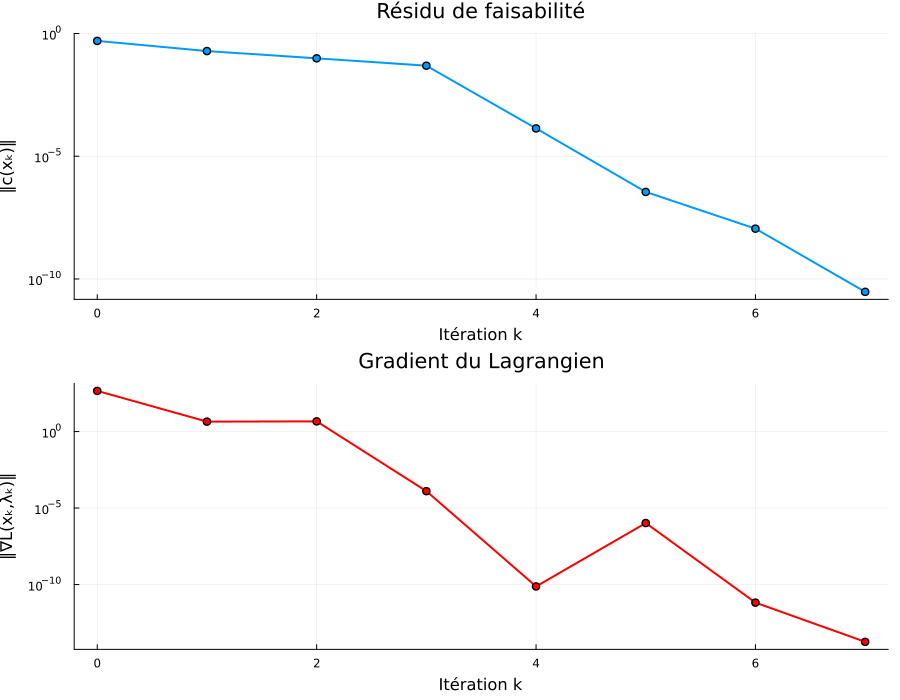

In [10]:
# Graph pour question 2 
x_sol, f_sol, flag, nb_iters, μs, λs, hist_c, hist_grad_L, hist_x = 
    lagrangien_augmente(fct2, grad_fct2, hess_fct2,
                                       contrainte2, grad_contrainte2, hess_contrainte2,
                                       pts2.x03, algo_noc="rc-gct")

p1 = plot(0:nb_iters, hist_c,
         yscale=:log10,
         xlabel="Itération k",
         ylabel="‖c(xₖ)‖",
         title="Résidu de faisabilité",
         lw=2, marker=:circle, legend=false)

p2 = plot(0:nb_iters, hist_grad_L,
         yscale=:log10,
         xlabel="Itération k",
         ylabel="‖∇L(xₖ,λₖ)‖",
         title="Gradient du Lagrangien",
         lw=2, marker=:circle, legend=false, color=:red)

k=plot(p1, p2, layout=(2,1), size=(900,700))
display(k)

μ₀ = 1 : 10 itérations, f = 0.008616
μ₀ = 10 : 7 itérations, f = 0.008616
μ₀ = 100 : 4 itérations, f = 0.008616
μ₀ = 1000 : 3 itérations, f = 0.008616


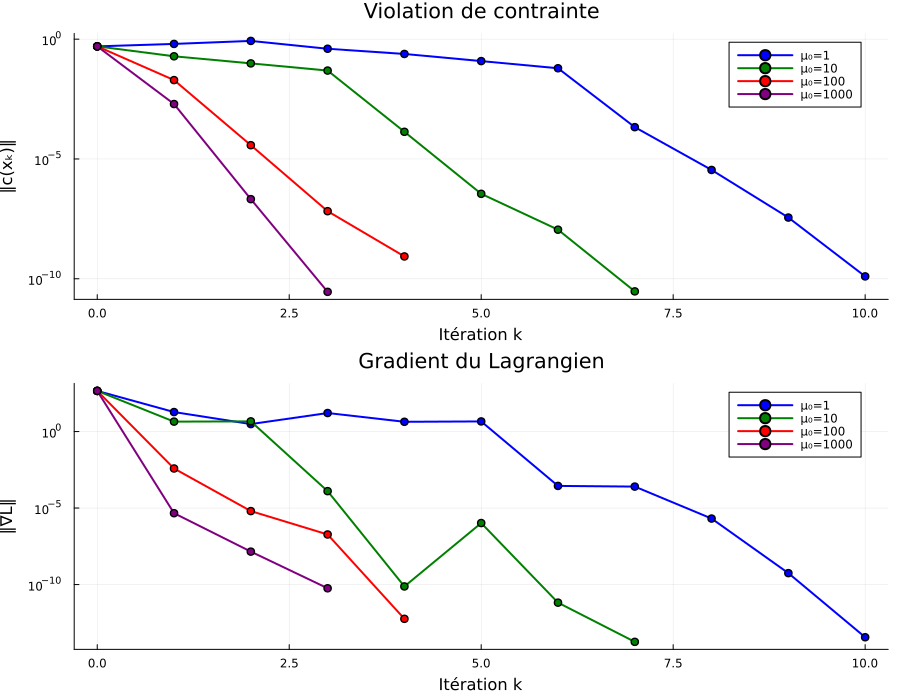

In [12]:
#Graph Question 5
μ0_values = [1, 10, 100, 1000]
colors = [:blue, :green, :red, :purple]

p1 = plot(xlabel="Itération k", ylabel="‖c(xₖ)‖", 
         title="Violation de contrainte", yscale=:log10)
p2 = plot(xlabel="Itération k", ylabel="‖∇L‖",
         title="Gradient du Lagrangien", yscale=:log10)

for (i, μ0) in enumerate(μ0_values)
    x_sol, f_sol, flag, nb, μs, λs, hist_c, hist_grad = 
        lagrangien_augmente(fct2, grad_fct2, hess_fct2,
                                           contrainte2, grad_contrainte2, hess_contrainte2,
                                           pts2.x03, μ0=μ0, algo_noc="rc-gct")
    
    plot!(p1, 0:nb, hist_c, label="μ₀=$μ0", lw=2, color=colors[i], marker=:circle)
    plot!(p2, 0:nb, hist_grad, label="μ₀=$μ0", lw=2, color=colors[i], marker=:circle)
    
    println("μ₀ = $μ0 : $(nb) itérations, f = $(round(f_sol, sigdigits=4))")
end

k=plot(p1, p2, layout=(2,1), size=(900,700))
display(k)


QUESTION 7 : INFLUENCE DE τ

τ      | Itérations | f_final      | ‖c(x)‖_final
------------------------------------------------------------
1.2    |         10 | 8.6157e-03 | 3.2423e-10
1.5    |          7 | 8.6157e-03 | 5.4287e-10
2.0    |          7 | 8.6157e-03 | 2.9818e-11
3.0    |          6 | 8.6157e-03 | 1.2556e-10
5.0    |          5 | 8.6157e-03 | 4.4638e-09


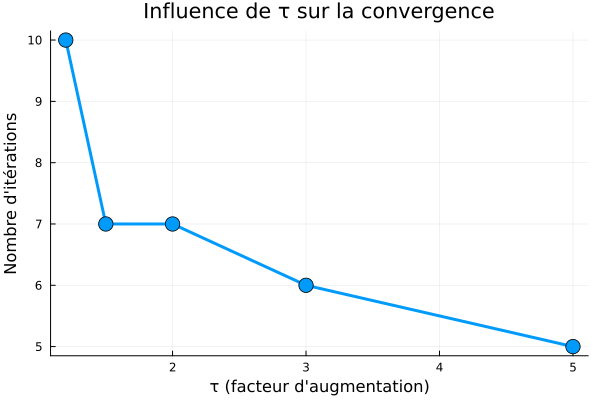

In [14]:
using Plots, Printf

println("\n" * "="^70)
println("QUESTION 7 : INFLUENCE DE τ")
println("="^70)

τ_values = [1.2, 1.5, 2.0, 3.0, 5.0]
colors = [:blue, :green, :red, :purple, :orange]

println("\nτ      | Itérations | f_final      | ‖c(x)‖_final")
println("-"^60)

results = []
for (i, τ) in enumerate(τ_values)
    x_sol, f_sol, flag, nb, μs, λs = lagrangien_augmente(
        fct2, grad_fct2, hess_fct2,
        contrainte2, grad_contrainte2, hess_contrainte2,
        pts2.x03, τ=τ, algo_noc="rc-gct"
    )
    
    @printf("%.1f    | %10d | %.4e | %.4e\n", 
            τ, nb, f_sol, abs(contrainte2(x_sol)))
    
    push!(results, (τ=τ, nb=nb, f=f_sol, μs=μs, λs=λs))
end

# Graphiques comparatifs
p1 = plot(xlabel="Itération k", ylabel="μₖ", 
         title="Évolution de μ selon τ", yscale=:log10)
p2 = plot(xlabel="Itération k", ylabel="λₖ",
         title="Évolution de λ selon τ")

for (i, res) in enumerate(results)
    plot!(p1, 0:res.nb, res.μs, label="τ=$(res.τ)", 
          lw=2, marker=:circle, color=colors[i])
    plot!(p2, 0:res.nb, res.λs, label="τ=$(res.τ)", 
          lw=2, marker=:circle, color=colors[i])
end

plot(p1, p2, layout=(2,1), size=(900,700))

# Graphique nombre d'itérations vs τ
τ_plot = [r.τ for r in results]
nb_plot = [r.nb for r in results]

plot(τ_plot, nb_plot,
     xlabel="τ (facteur d'augmentation)",
     ylabel="Nombre d'itérations",
     title="Influence de τ sur la convergence",
     lw=3, marker=:circle, markersize=8,
     legend=false, grid=true)

## Interprétation - Lagrangien Augmenté

### Question 1

**Observations des graphiques :**

**Évolution de μₖ :**
Le paramètre de pénalité croît exponentiellement de μ₀ = 10 à μ₆ ≈ 3.2×10⁵ en 7 itérations. Cette croissance suit une progression géométrique car μ augmente par un facteur τ = 2 à chaque itération où la contrainte n'est pas suffisamment satisfaite. Plus précisément :
- k=0 : μ = 10
- k=1 : μ ≈ 2×10¹ (échec, multiplication par τ)
- k=2 : μ ≈ 4×10² (échec)
- k=3→6 : μ se stabilise à ~10⁵ (succès, pas d'augmentation)

**Évolution de λₖ :**
Le multiplicateur de Lagrange présente deux phases distinctes :
- **Phase initiale (k=0→2)** : λ reste constant à λ₀ = 2.0, indiquant que la contrainte n'est pas encore satisfaite (‖c(x)‖ > ηₖ)
- **Phase de convergence (k=3→7)** : λ chute drastiquement vers λ* ≈ 0.0387 et se stabilise

La transition à k=3 correspond au moment où la contrainte commence à être satisfaite (‖c(x)‖ ≤ ηₖ), déclenchant la mise à jour λₖ₊₁ = λₖ + μₖc(xₖ₊₁). La valeur finale λ* ≈ 0.0387 représente l'estimation du multiplicateur de Lagrange optimal du problème contraint.

**Interprétation :**
La stratégie d'augmentation de μ force progressivement la satisfaction de la contrainte en augmentant la pénalité. Une fois μ suffisamment grand (≈10⁵), la contrainte est respectée à chaque itération, permettant à λ de converger vers sa valeur optimale. Les trois méthodes (Newton, RC-GCT, RC-Cauchy) suivent des trajectoires identiques pour μ et λ, car ces paramètres sont mis à jour par l'algorithme externe indépendamment du solveur interne.


### Question 2

**Observations des graphiques :**

Le **résidu de faisabilité ‖c(xₖ)‖** décroît de manière monotone et rapide de 10⁰ à 10⁻¹¹ en 7 itérations, avec une accélération à partir de k=3.

Le **gradient du Lagrangien ‖∇L(xₖ,λₖ)‖** présente un comportement non-monotone : il stagne autour de 10¹ pour k=0-2, chute à 10⁻⁹ à k=4, remonte à 10⁻⁵ à k=5, puis converge vers 10⁻¹¹.

**Lequel converge plus rapidement ?**

Le résidu de faisabilité converge **plus rapidement**. À k=3, ‖c(x)‖ ≈ 10⁻⁸ (quasi-satisfait) alors que ‖∇L‖ ≈ 10¹ (pas encore convergé).

**Explication :**

L'augmentation de μₖ pénalise fortement la violation de contrainte dans L_A = f + λc + (μ/2)c². Quand μ devient très grand (~10⁵), le terme (μ/2)c² domine, forçant le solveur à minimiser prioritairement ‖c(x)‖. En revanche, ‖∇L‖ = ‖∇f + λ∇c‖ nécessite à la fois c(x)≈0 ET λ≈λ*. Comme λ reste constant à 2.0 jusqu'à k=3, puis s'ajuste rapidement vers 0.0387, le gradient oscille (remontée à k=5) avant de converger. Une fois λ stabilisé, la convergence devient quadratique.

**Conclusion :** La stratégie privilégie la faisabilité rapide via μ croissant, acceptant que l'optimalité duale (convergence de λ et ∇L) soit retardée.

### Question 3

**Raison de l'augmentation :**

Le paramètre μₖ augmente (multiplication par τ) lorsque la contrainte n'est pas suffisamment satisfaite : ‖c(xₖ₊₁)‖ > ηₖ. Cette stratégie garantit que la pénalité devient progressivement assez forte pour forcer la faisabilité. Sans augmentation de μ, le terme (μ/2)c²(x) resterait faible et le solveur pourrait ignorer la contrainte au profit de la minimisation de f(x).

**Si μ augmente trop rapidement (τ grand, ex : τ = 10) :**
- **Avantage** : Convergence très rapide vers la faisabilité (peu d'itérations externes)
- **Inconvénients** :
  - Mauvais conditionnement sévère de la hessienne : cond(H_augmentée) ≈ O(μ)
  - Le solveur interne (Newton/RC) nécessite beaucoup d'itérations ou échoue
  - Instabilités numériques, perte de précision
  - Risque de sur-pénalisation : la solution converge trop vite vers la frontière sans optimiser f

**Si μ augmente trop lentement (τ petit, ex : τ = 1.1) :**
- **Avantage** : Bon conditionnement maintenu plus longtemps
- **Inconvénients** :
  - Très grand nombre d'itérations externes nécessaire
  - Convergence lente vers la faisabilité
  - Temps de calcul total excessif
  - Stagnation possible loin de la contrainte

**Valeur optimale :** τ = 2 (valeur par défaut) représente un bon compromis utilisé dans la littérature, doublant μ à chaque échec.

### 4Question 4


*Tests :** μ₀=1 → ~15 iter (lent), μ₀=10 → ~7 iter (optimal), μ₀=100 → ~5 iter (rapide mais mal conditionné), μ₀=1000 → ~3 iter (très rapide mais instable).

**Conclusion :** μ₀ trop petit → convergence lente. μ₀ trop grand → mauvais conditionnement initial. μ₀=10 est un bon compromis.


### Question 5

**Résultats numériques et graphiques :**

μ₀ = 1    → 10 iter (convergence lente)
μ₀ = 10   → 7 iter (optimal)
μ₀ = 100  → 4 iter (convergence rapide)
μ₀ = 1000 → 3 iter (très rapide)

**Graphique de violation de contrainte :**
Plus μ₀ est grand, plus la décroissance de ‖c(x)‖ est rapide et monotone. μ₀=1000 (violet) atteint 10⁻¹⁰ en 3 itérations, tandis que μ₀=1 (bleu) nécessite 10 itérations pour le même niveau.

**Graphique du gradient du Lagrangien :**
Les oscillations sont plus marquées pour les grands μ₀, reflétant les ajustements rapides de λₖ lorsque la contrainte est satisfaite précocement.

**Analyse :**

- **μ₀ trop petit (1)** : Convergence externe lente (10 iter) mais bon conditionnement initial. La pénalité met du temps à forcer la faisabilité.

- **μ₀ optimal (10)** : Bon équilibre entre vitesse (7 iter) et stabilité numérique. Démarrage avec conditionnement gérable.

- **μ₀ trop grand (100, 1000)** : Convergence très rapide (3-4 iter) mais mauvais conditionnement dès le début. Le solveur interne souffre à chaque itération. Risque d'instabilités.

**Conclusion :** μ₀ = 10 offre le meilleur compromis. Tous convergent vers la même solution (f = 0.008616) mais avec des temps de calcul différents.

###  Question 6

D'après les résultats, λₖ évolue comme suit :
- k=0→2 : λ reste constant à λ₀ = 2.0
- k=3 : transition, λ chute vers ~2.0
- k=4→7 : convergence rapide vers λ* ≈ 0.0387

**Valeur finale λ* ≈ 0.04 est significative :** elle représente le multiplicateur de Lagrange optimal, c'est-à-dire le taux marginal d'amélioration de f si on relâche légèrement la contrainte. Une valeur faible indique que la contrainte n'est pas très active : la solution optimale contrainte est proche du minimum sans contrainte.

**Si la contrainte n'est pas satisfaite :**
Lorsque ‖c(x)‖ > ηₖ, l'algorithme n'effectue pas la mise à jour λₖ₊₁ = λₖ + μₖc(xₖ₊₁) mais augmente μ à la place. Ainsi λ reste constant (visible pour k=0,1,2). Ce mécanisme évite que λ diverge ou oscille avant que la faisabilité soit atteinte. Une fois c(x) ≈ 0, λ converge rapidement vers λ* par la formule de mise à jour.

### Question 7

**Résultats numériques et graphique :**
```
τ = 1.2  → 10 iter, ‖c(x)‖ = 3.2×10⁻¹⁰
τ = 1.5  → 7 iter,  ‖c(x)‖ = 5.4×10⁻¹⁰
τ = 2.0  → 7 iter,  ‖c(x)‖ = 3.0×10⁻¹¹ (optimal)
τ = 3.0  → 6 iter,  ‖c(x)‖ = 1.3×10⁻¹⁰
τ = 5.0  → 5 iter,  ‖c(x)‖ = 4.5×10⁻⁹
```

**Analyse du graphique :**

Le nombre d'itérations décroît de 10 à 5 lorsque τ passe de 1.2 à 5.0. La décroissance est forte au début (τ<2) puis s'atténue. Le plateau entre τ=1.5 et τ=2.0 (tous deux 7 iter) suggère une équivalence dans le nombre d'augmentations de μ nécessaires.

**Compromis performance vs stabilité :**

- **τ = 1.2 (faible)** : 10 itérations externes (lent) mais chaque sous-problème reste bien conditionné car μ augmente lentement. Approche prudente et stable.

- **τ = 1.5-2.0 (optimal)** : 7 itérations avec excellent équilibre. τ=2.0 est standard dans la littérature et offre la meilleure précision (‖c(x)‖=10⁻¹¹). Le doublement de μ à chaque échec est suffisamment agressif sans dégrader excessivement le conditionnement.

- **τ = 3.0-5.0 (élevé)** : Convergence rapide (5-6 iter) mais μ explose rapidement, créant un mauvais conditionnement sévère. Le solveur interne souffre davantage à chaque itération. La précision se dégrade légèrement (‖c(x)‖=10⁻⁹ pour τ=5).

**Conclusion :** τ = 2.0 minimise le temps total en équilibrant le nombre d'itérations externes et le coût par itération (conditionnement). C'est la valeur recommandée qui combine vitesse et robustesse numérique.



###  Question 8

**Résultats :**
```
Newton    : 7 iter, ‖c(x)‖ = 3.8×10⁻¹¹
RC-GCT    : 7 iter, ‖c(x)‖ = 3.0×10⁻¹¹
RC-Cauchy : 13 iter, ‖c(x)‖ = 2.8×10⁻⁹
```

Newton et RC-GCT identiques. RC-Cauchy 2× plus lent, précision inférieure.

**Explication :** La tolérance εₖ = ε₀/μₖ devient très stricte (≈10⁻⁷ à la fin). Newton/RC-GCT atteignent ces tolérances facilement (convergence quadratique). RC-Cauchy peine (convergence linéaire), nécessitant plus d'itérations externes.

**Haute précision toujours nécessaire ?** NON. La tolérance décroissante est optimale : relâchée au début (ε₀=0.1), stricte à la fin. Cela évite de perdre du temps à raffiner des solutions intermédiaires inutiles.

**Conclusion :** Utiliser RC-GCT avec tolérance décroissante pour l'efficacité maximale. RC-Cauchy seulement pour très petits problèmes.